In [58]:
import numpy as np
import matplotlib.pyplot as plt

In [59]:
fname = "final_GSFSC_data.txt"
plt.rcParams["font.sans-serif"] = ['Arial']

def read_data(fname):
    freqs = []
    corrs_nomask = []
    with open(fname, 'r') as f:
        lines = f.readlines()
        lines = lines[2:]
        for line in lines:
            data = line.split("\t")
            freqs.append(float(data[1]))
            corrs_nomask.append(float(data[2]))
    return np.array(freqs), np.array(corrs_nomask)

freq, cc_nomask = read_data(fname)

In [60]:
cutoff = 0.143

for i in range(len(freq)):
    if cc_nomask[i] <= cutoff:
        print("Resolution without mask is {}, at index {}.".format(1/freq[i], i))
        break

Resolution without mask is 18.672741531911715, at index 55.


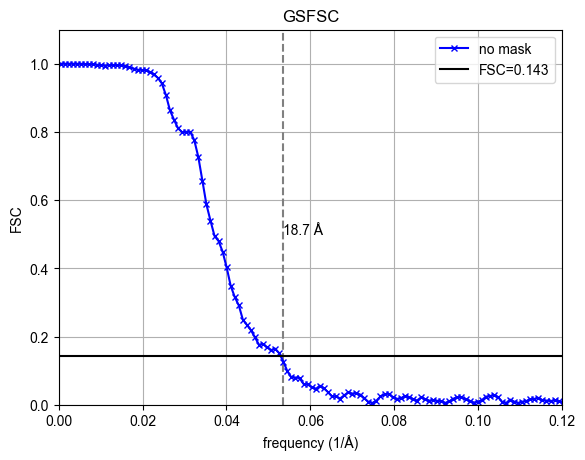

In [61]:
w = (165/10)/2.54 # mm to inches
f = plt.figure(figsize=(w, 3*w/4))
plt.vlines(freq[55], 0, 1.5, color="grey", linestyle="--");
plt.plot(freq, cc_nomask, label="no mask", color="blue", linestyle="-", marker='x', markersize=5);
plt.plot(freq, [0.143 for i in range(len(freq))], label="FSC=0.143", color="black", linestyle="-");
plt.legend(); plt.grid();
plt.xlabel("frequency (1/Å)");
plt.ylabel("FSC");
plt.title("GSFSC");
plt.xlim(0, 0.12); plt.ylim(0, 1.1);
plt.text(freq[55], 0.5, "18.7 Å");

plt.savefig("GSFSC.png", format='png', dpi=600, transparent=True);